# Cross-Dataset Failure Analysis in Brain MRI Classification

This notebook investigates cross-dataset failure patterns in four-class brain MRI classification using the BDNeuro and PMRAM datasets.

The analysis focuses on cross-dataset classification performance, class-specific errors, dataset-level image characteristics, and model sensitivity to controlled contrast changes. EfficientNet-B0 and ResNet18 are evaluated to examine whether observed failure patterns are consistent across model architectures.

In [2]:
import pandas as pd
import torchvision

df = pd.read_csv("final_four_class_clean_dataset.csv")

bdneuro_df = df[df["dataset"] == "BDNeuro"].copy()
pmram_df = df[df["dataset"] == "PMRAM"].copy()

print("CSV OK")
print("Total images:", len(df))
print(df["dataset"].value_counts())



CSV OK
Total images: 7351
dataset
BDNeuro    5941
PMRAM      1410
Name: count, dtype: int64


## 1. Cross-Dataset Evaluation

Models trained on PMRAM are evaluated on BDNeuro to examine performance under dataset shift. Confusion matrices and class-specific errors are analyzed, with particular attention to Meningioma, which shows the largest degradation in the PMRAM-to-BDNeuro direction.


In [3]:
import torch.nn as nn
from torchvision import models

model_pm = models.efficientnet_b0(weights=None)

in_features = model_pm.classifier[1].in_features
model_pm.classifier[1] = nn.Linear(in_features, 4)

model_pm.load_state_dict(
    torch.load(
        "efficientnet_b0_pmram_best.pth",
        map_location="cpu"
    )
)

model_pm.eval()

print("PMRAM EfficientNet loaded successfully")


PMRAM EfficientNet loaded successfully


In [4]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


bd_df = df[df["dataset"] == "BDNeuro"].copy()

class_to_idx = {
    "glioma": 0,
    "meningioma": 1,
    "no_tumor": 2,
    "pituitary": 3
}

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class BrainDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["filepath"]).convert("RGB")
        image = eval_transform(image)

        label = class_to_idx[row["class_label"]]

        return image, label

bd_dataset = BrainDataset(bd_df)


bd_loader = DataLoader(
    bd_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)

print("BDNeuro DataLoader OK")
print("Images:", len(bd_dataset))
print("Batches:", len(bd_loader))


BDNeuro DataLoader OK
Images: 5941
Batches: 743


In [5]:
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

true_labels = []
pred_labels = []

print("Starting prediction...")

model_pm.eval()

with torch.no_grad():
    for i, (images, labels) in enumerate(bd_loader):

        outputs = model_pm(images)
        preds = outputs.argmax(dim=1)

        true_labels.extend(labels.numpy())
        pred_labels.extend(preds.numpy())

        
        if (i + 1) % 100 == 0:
            print(f"{i + 1} / {len(bd_loader)} batches completed")

print("Prediction finished.")

cm = confusion_matrix(true_labels, pred_labels)

cm_df = pd.DataFrame(
    cm,
    index=[
        "True Glioma",
        "True Meningioma",
        "True No Tumor",
        "True Pituitary"
    ],
    columns=[
        "Pred Glioma",
        "Pred Meningioma",
        "Pred No Tumor",
        "Pred Pituitary"
    ]
)

print("\nCONFUSION MATRIX")
display(cm_df)


men = cm[1]

print("\nMENINGIOMA:")
print("Predicted as Glioma:", men[0])
print("Correctly predicted as Meningioma:", men[1])
print("Predicted as No Tumor:", men[2])
print("Predicted as Pituitary:", men[3])

print("\nTotal Meningioma:", men.sum())
print("Meningioma errors:", men.sum() - men[1])


Starting prediction...
100 / 743 batches completed
200 / 743 batches completed
300 / 743 batches completed
400 / 743 batches completed
500 / 743 batches completed
600 / 743 batches completed
700 / 743 batches completed
Prediction finished.

CONFUSION MATRIX


,Pred Glioma,Pred Meningioma,Pred No Tumor,Pred Pituitary
True Glioma,1831,8,342,10
True Meningioma,612,249,323,294
True No Tumor,6,5,773,3
True Pituitary,19,30,351,1085



MENINGIOMA:
Predicted as Glioma: 612
Correctly predicted as Meningioma: 249
Predicted as No Tumor: 323
Predicted as Pituitary: 294

Total Meningioma: 1478
Meningioma errors: 1229


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

device = torch.device("cpu")

# ResNet18 pretrained on ImageNet
model_resnet_pm = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

# 4 classes
model_resnet_pm.fc = nn.Linear(
    model_resnet_pm.fc.in_features,
    4
)

model_resnet_pm = model_resnet_pm.to(device)

criterion_resnet_pm = nn.CrossEntropyLoss()

optimizer_resnet_pm = optim.Adam(
    model_resnet_pm.parameters(),
    lr=0.0001
)

print("ResNet18 PMRAM model ready")
print("Device:", device)


ResNet18 PMRAM model ready
Device: cpu


In [11]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

# ============================================================
# PMRAM SPLIT — EXACTLY SAME SETUP AS ORIGINAL EXPERIMENT
# ============================================================

pmram_df = df[df["dataset"] == "PMRAM"].copy()

pm_train_df, pm_temp_df = train_test_split(
    pmram_df,
    test_size=0.30,
    stratify=pmram_df["class_label"],
    random_state=42
)

pm_val_df, pm_test_df = train_test_split(
    pm_temp_df,
    test_size=0.50,
    stratify=pm_temp_df["class_label"],
    random_state=42
)

# Training augmentation — same as original ResNet experiment
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

pm_train_dataset = BrainDataset(pm_train_df)
pm_val_dataset = BrainDataset(pm_val_df)

# BrainDataset فعلی از eval_transform استفاده می‌کند.
# برای train augmentation یک نسخه مخصوص train می‌سازیم.

class TrainBrainDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["filepath"]).convert("RGB")
        image = train_transform(image)

        label = class_to_idx[row["class_label"]]

        return image, label


pm_train_dataset = TrainBrainDataset(pm_train_df)
pm_val_dataset = BrainDataset(pm_val_df)

pm_train_loader = DataLoader(
    pm_train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

pm_val_loader = DataLoader(
    pm_val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

print("PMRAM Train:", len(pm_train_dataset))
print("PMRAM Validation:", len(pm_val_dataset))

# ============================================================
# TRAIN 5 EPOCHS + SAVE BEST MODEL
# ============================================================

best_val_accuracy = 0.0

for epoch in range(5):

    # ---------- TRAIN ----------
    model_resnet_pm.train()

    train_correct = 0
    train_total = 0
    train_loss = 0.0

    for images, labels in pm_train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer_resnet_pm.zero_grad()

        outputs = model_resnet_pm(images)

        loss = criterion_resnet_pm(
            outputs,
            labels
        )

        loss.backward()
        optimizer_resnet_pm.step()

        train_loss += (
            loss.item() * images.size(0)
        )

        predictions = outputs.argmax(dim=1)

        train_correct += (
            predictions == labels
        ).sum().item()

        train_total += labels.size(0)

    train_accuracy = (
        train_correct / train_total
    )

    train_loss = (
        train_loss / train_total
    )

    # ---------- VALIDATION ----------
    model_resnet_pm.eval()

    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in pm_val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_resnet_pm(images)

            predictions = outputs.argmax(dim=1)

            val_correct += (
                predictions == labels
            ).sum().item()

            val_total += labels.size(0)

    val_accuracy = (
        val_correct / val_total
    )

    print(
        f"Epoch {epoch+1}/5 | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

    # ---------- SAVE BEST ----------
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            model_resnet_pm.state_dict(),
            "resnet18_pmram_best.pth"
        )

        print(
            " >>> Best model saved"
        )

print("\nTraining finished.")
print(
    "Best Validation Accuracy:",
    best_val_accuracy
)
print(
    "Saved as: resnet18_pmram_best.pth"
)


PMRAM Train: 987
PMRAM Validation: 211
Epoch 1/5 | Train Loss: 0.5288 | Train Acc: 0.7964 | Val Acc: 0.8957
 >>> Best model saved
Epoch 2/5 | Train Loss: 0.1438 | Train Acc: 0.9554 | Val Acc: 0.9242
 >>> Best model saved
Epoch 3/5 | Train Loss: 0.0707 | Train Acc: 0.9807 | Val Acc: 0.9526
 >>> Best model saved
Epoch 4/5 | Train Loss: 0.0495 | Train Acc: 0.9838 | Val Acc: 0.9668
 >>> Best model saved
Epoch 5/5 | Train Loss: 0.0197 | Train Acc: 0.9959 | Val Acc: 0.9858
 >>> Best model saved

Training finished.
Best Validation Accuracy: 0.985781990521327
Saved as: resnet18_pmram_best.pth


In [12]:
from sklearn.metrics import accuracy_score, classification_report

# Load the BEST saved model
model_resnet_pm.load_state_dict(
    torch.load(
        "resnet18_pmram_best.pth",
        map_location="cpu"
    )
)

model_resnet_pm.eval()

# PMRAM test dataset
pm_test_dataset = BrainDataset(pm_test_df)

pm_test_loader = DataLoader(
    pm_test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

true_labels = []
pred_labels = []

with torch.no_grad():

    for images, labels in pm_test_loader:

        outputs = model_resnet_pm(images)
        preds = outputs.argmax(dim=1)

        true_labels.extend(labels.numpy())
        pred_labels.extend(preds.numpy())

accuracy = accuracy_score(
    true_labels,
    pred_labels
)

print("PMRAM INTERNAL TEST ACCURACY:")
print(accuracy)

print("\nCLASSIFICATION REPORT:")

print(
    classification_report(
        true_labels,
        pred_labels,
        target_names=[
            "Glioma",
            "Meningioma",
            "No Tumor",
            "Pituitary"
        ],
        digits=4
    )
)


PMRAM INTERNAL TEST ACCURACY:
0.9716981132075472

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      Glioma     0.9808    0.9107    0.9444        56
  Meningioma     0.9412    0.9796    0.9600        49
    No Tumor     0.9808    1.0000    0.9903        51
   Pituitary     0.9825    1.0000    0.9912        56

    accuracy                         0.9717       212
   macro avg     0.9713    0.9726    0.9715       212
weighted avg     0.9721    0.9717    0.9714       212



In [13]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# BDNeuro کامل
bd_external_dataset_resnet = BrainDataset(bd_df)

bd_external_loader_resnet = DataLoader(
    bd_external_dataset_resnet,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

true_bd = []
pred_bd = []

model_resnet_pm.eval()

print("Starting ResNet prediction on BDNeuro...")

with torch.no_grad():

    for i, (images, labels) in enumerate(bd_external_loader_resnet):

        outputs = model_resnet_pm(images)
        preds = outputs.argmax(dim=1)

        true_bd.extend(labels.numpy())
        pred_bd.extend(preds.numpy())

        if (i + 1) % 100 == 0:
            print(
                f"{i + 1} / {len(bd_external_loader_resnet)} batches completed"
            )

print("Prediction finished.")

# Confusion Matrix
cm_resnet = confusion_matrix(
    true_bd,
    pred_bd
)

cm_resnet_df = pd.DataFrame(
    cm_resnet,
    index=[
        "True Glioma",
        "True Meningioma",
        "True No Tumor",
        "True Pituitary"
    ],
    columns=[
        "Pred Glioma",
        "Pred Meningioma",
        "Pred No Tumor",
        "Pred Pituitary"
    ]
)

print("\nRESNET18 CONFUSION MATRIX:")
display(cm_resnet_df)

# Meningioma specifically
men = cm_resnet[1]

print("\nMENINGIOMA:")
print("Predicted as Glioma:", men[0])
print("Correctly predicted as Meningioma:", men[1])
print("Predicted as No Tumor:", men[2])
print("Predicted as Pituitary:", men[3])

print("\nTotal Meningioma:", men.sum())
print("Meningioma errors:", men.sum() - men[1])

# Overall external accuracy
resnet_external_accuracy = (
    (cm_resnet.diagonal().sum()) / cm_resnet.sum()
)

print(
    "\nBDNeuro External Accuracy:",
    resnet_external_accuracy
)

# Save it
cm_resnet_df.to_csv(
    "resnet18_pmram_to_bdneuro_confusion_matrix.csv"
)

print(
    "\nSaved: resnet18_pmram_to_bdneuro_confusion_matrix.csv"
)


Starting ResNet prediction on BDNeuro...
100 / 372 batches completed
200 / 372 batches completed
300 / 372 batches completed
Prediction finished.

RESNET18 CONFUSION MATRIX:


,Pred Glioma,Pred Meningioma,Pred No Tumor,Pred Pituitary
True Glioma,1959,33,96,103
True Meningioma,617,337,69,455
True No Tumor,11,14,757,5
True Pituitary,34,44,44,1363



MENINGIOMA:
Predicted as Glioma: 617
Correctly predicted as Meningioma: 337
Predicted as No Tumor: 69
Predicted as Pituitary: 455

Total Meningioma: 1478
Meningioma errors: 1141

BDNeuro External Accuracy: 0.7433092072041744

Saved: resnet18_pmram_to_bdneuro_confusion_matrix.csv


In [14]:
from PIL import Image
import pandas as pd
import os


bd_men = df[
    (df["dataset"] == "BDNeuro") &
    (df["class_label"] == "meningioma")
].copy()

pm_men = df[
    (df["dataset"] == "PMRAM") &
    (df["class_label"] == "meningioma")
].copy()

print("BDNeuro Meningioma:", len(bd_men))
print("PMRAM Meningioma:", len(pm_men))

def get_image_sizes(dataframe):
    sizes = []

    for path in dataframe["filepath"]:
        with Image.open(path) as img:
            sizes.append(img.size)

    return pd.Series(sizes).value_counts()

print("\nBDNeuro image sizes:")
print(get_image_sizes(bd_men).head(10))

print("\nPMRAM image sizes:")
print(get_image_sizes(pm_men).head(10))


BDNeuro Meningioma: 1478
PMRAM Meningioma: 327

BDNeuro image sizes:
(512, 512)    948
(224, 224)    409
(225, 225)      8
(442, 442)      3
(210, 240)      2
(200, 223)      2
(201, 251)      2
(212, 237)      2
(228, 221)      1
(300, 258)      1
Name: count, dtype: int64

PMRAM image sizes:
(512, 512)    327
Name: count, dtype: int64


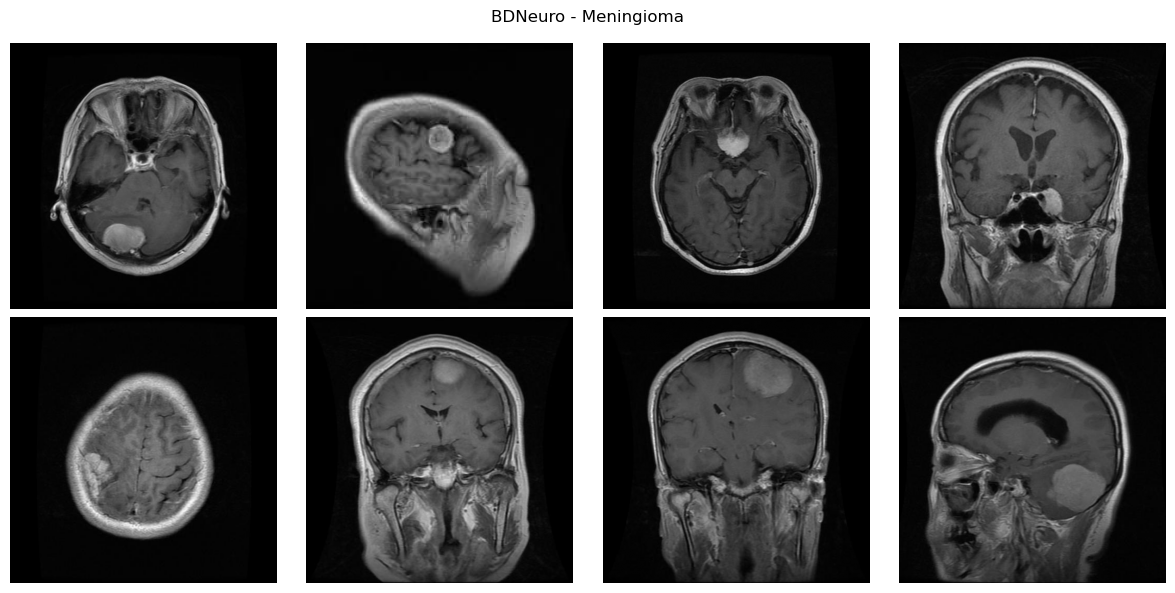

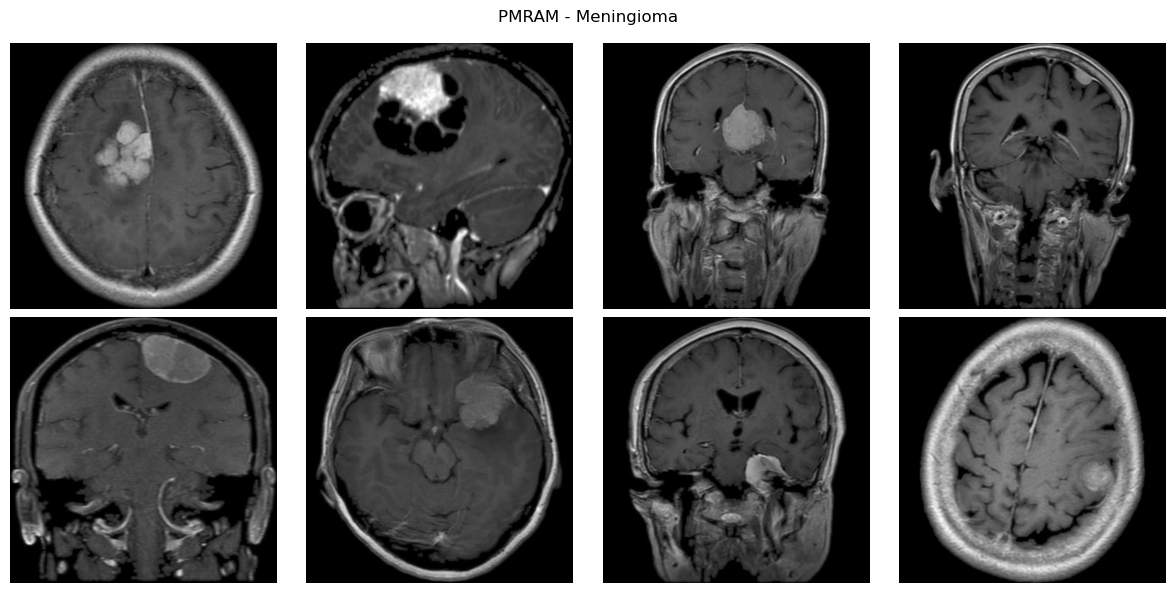

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


bd_samples = bd_men.sample(
    n=8,
    random_state=42
)

pm_samples = pm_men.sample(
    n=8,
    random_state=42
)

# -------------------------
# BDNeuro
# -------------------------

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax, (_, row) in zip(
    axes.flatten(),
    bd_samples.iterrows()
):
    img = Image.open(row["filepath"])
    ax.imshow(img, cmap="gray")
    ax.axis("off")

plt.suptitle("BDNeuro - Meningioma")
plt.tight_layout()
plt.show()

# -------------------------
# PMRAM
# -------------------------

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax, (_, row) in zip(
    axes.flatten(),
    pm_samples.iterrows()
):
    img = Image.open(row["filepath"])
    ax.imshow(img, cmap="gray")
    ax.axis("off")

plt.suptitle("PMRAM - Meningioma")
plt.tight_layout()
plt.show()


In [18]:
import numpy as np
import pandas as pd
from PIL import Image
import os


bd_men = bdneuro_df[
    bdneuro_df["class_label"] == "meningioma"
].copy()

pm_men = pmram_df[
    pmram_df["class_label"] == "meningioma"
].copy()


def analyze_images(dataframe, dataset_name):
    
    results = []

    total = len(dataframe)

    print(f"\nAnalyzing {dataset_name}...")
    print("Total images:", total)

    for i, (_, row) in enumerate(dataframe.iterrows(), start=1):

        try:
            
            img = Image.open(row["filepath"]).convert("L")

            arr = np.array(img, dtype=np.float32)

            results.append({
                "dataset": dataset_name,
                "width": img.width,
                "height": img.height,
                "mean_intensity": arr.mean(),
                "std_intensity": arr.std(),
                "min_intensity": arr.min(),
                "max_intensity": arr.max()
            })

        except Exception as e:
            print("Problem:", row["filepath"])

        if i % 250 == 0:
            print(f"{i} / {total} completed")

    return pd.DataFrame(results)



bd_stats = analyze_images(
    bd_men,
    "BDNeuro"
)

pm_stats = analyze_images(
    pm_men,
    "PMRAM"
)



meningioma_image_stats = pd.concat(
    [bd_stats, pm_stats],
    ignore_index=True
)


print("\n==============================")
print("MENINGIOMA IMAGE STATISTICS")
print("==============================")

summary = meningioma_image_stats.groupby("dataset")[
    ["mean_intensity", "std_intensity"]
].agg(["mean", "std", "median"])

display(summary.round(2))


print("\nIMAGE SIZE SUMMARY:")

print("\nBDNeuro:")
print(
    bd_stats[["width", "height"]]
    .value_counts()
    .head(10)
)

print("\nPMRAM:")
print(
    pm_stats[["width", "height"]]
    .value_counts()
    .head(10)
)


meningioma_image_stats.to_csv(
    "meningioma_cross_dataset_image_statistics.csv",
    index=False
)

print(
    "\nSaved as: meningioma_cross_dataset_image_statistics.csv"
)



Analyzing BDNeuro...
Total images: 1478
250 / 1478 completed
500 / 1478 completed
750 / 1478 completed
1000 / 1478 completed
1250 / 1478 completed

Analyzing PMRAM...
Total images: 327
250 / 327 completed

MENINGIOMA IMAGE STATISTICS


mean_intensity               std_intensity                  
                  mean    std median          mean    std     median
dataset                                                             
BDNeuro      44.599998  16.41  41.52     46.150002   8.63  45.349998
PMRAM        58.619999  15.76  54.98     53.599998  12.47  50.580002


IMAGE SIZE SUMMARY:

BDNeuro:
width  height
512    512       948
224    224       409
225    225         8
442    442         3
201    251         2
210    240         2
212    237         2
200    223         2
306    306         1
329    314         1
Name: count, dtype: int64

PMRAM:
width  height
512    512       327
Name: count, dtype: int64

Saved as: meningioma_cross_dataset_image_statistics.csv


In [19]:
import numpy as np
import pandas as pd
from PIL import Image

classes = ["glioma", "meningioma", "no_tumor", "pituitary"]

results = []

for dataset_name, dataset_df in [
    ("BDNeuro", bdneuro_df),
    ("PMRAM", pmram_df)
]:
    
    print(f"\n========== {dataset_name} ==========")

    for class_name in classes:

        class_df = dataset_df[
            dataset_df["class_label"] == class_name
        ]

        print(f"\nAnalyzing {class_name}: {len(class_df)} images")

        for i, (_, row) in enumerate(class_df.iterrows(), start=1):

            try:
                img = Image.open(row["filepath"]).convert("L")
                arr = np.array(img, dtype=np.float32)

                results.append({
                    "dataset": dataset_name,
                    "class": class_name,
                    "mean_intensity": arr.mean(),
                    "std_intensity": arr.std(),
                    "width": img.width,
                    "height": img.height
                })

            except Exception as e:
                print("Problem reading:", row["filepath"])

            if i % 500 == 0:
                print(f"{i} / {len(class_df)} completed")


# Create dataframe
all_class_image_stats = pd.DataFrame(results)


# Summary
summary_all_classes = (
    all_class_image_stats
    .groupby(["dataset", "class"])
    .agg(
        n=("mean_intensity", "size"),
        mean_brightness=("mean_intensity", "mean"),
        median_brightness=("mean_intensity", "median"),
        brightness_sd=("mean_intensity", "std"),
        mean_contrast=("std_intensity", "mean"),
        median_contrast=("std_intensity", "median"),
        contrast_sd=("std_intensity", "std")
    )
    .reset_index()
)


print("\n==============================================")
print("ALL-CLASS CROSS-DATASET IMAGE STATISTICS")
print("==============================================")

display(summary_all_classes.round(2))


# Direct BDNeuro vs PMRAM differences
pivot_brightness = summary_all_classes.pivot(
    index="class",
    columns="dataset",
    values="mean_brightness"
)

pivot_brightness["PMRAM_minus_BDNeuro"] = (
    pivot_brightness["PMRAM"] -
    pivot_brightness["BDNeuro"]
)

print("\n==============================================")
print("BRIGHTNESS DIFFERENCE: PMRAM - BDNeuro")
print("==============================================")

display(pivot_brightness.round(2))


# Save results
all_class_image_stats.to_csv(
    "all_classes_cross_dataset_image_statistics.csv",
    index=False
)

summary_all_classes.to_csv(
    "all_classes_cross_dataset_summary.csv",
    index=False
)

print("\nSaved:")
print("all_classes_cross_dataset_image_statistics.csv")
print("all_classes_cross_dataset_summary.csv")



========== BDNeuro ==========

Analyzing glioma: 2191 images
500 / 2191 completed
1000 / 2191 completed
1500 / 2191 completed
2000 / 2191 completed

Analyzing meningioma: 1478 images
500 / 1478 completed
1000 / 1478 completed

Analyzing no_tumor: 787 images
500 / 787 completed

Analyzing pituitary: 1485 images
500 / 1485 completed
1000 / 1485 completed

========== PMRAM ==========

Analyzing glioma: 370 images

Analyzing meningioma: 327 images

Analyzing no_tumor: 341 images

Analyzing pituitary: 372 images

ALL-CLASS CROSS-DATASET IMAGE STATISTICS


,dataset,class,n,mean_brightness,median_brightness,brightness_sd,mean_contrast,median_contrast,contrast_sd
0,BDNeuro,glioma,2191,35.830002,33.639999,14.520000,39.090000,39.020000,8.40
1,BDNeuro,meningioma,1478,44.599998,41.520000,16.410000,46.150002,45.349998,8.63
2,BDNeuro,no_tumor,787,59.730000,56.630001,22.770000,57.360001,55.590000,15.85
3,BDNeuro,pituitary,1485,48.880001,48.639999,13.720000,40.959999,41.250000,5.97
4,PMRAM,glioma,370,39.889999,39.250000,11.630000,40.450001,40.759998,7.25
5,PMRAM,meningioma,327,58.619999,54.980000,15.760000,53.599998,50.580002,12.47
6,PMRAM,no_tumor,341,61.139999,57.959999,21.209999,59.110001,57.330002,15.50
7,PMRAM,pituitary,372,48.970001,50.139999,7.590000,41.430000,41.560001,4.56



BRIGHTNESS DIFFERENCE: PMRAM - BDNeuro


dataset,BDNeuro,PMRAM,PMRAM_minus_BDNeuro
class,,,
glioma,35.830002,39.889999,4.06
meningioma,44.599998,58.619999,14.02
no_tumor,59.730000,61.139999,1.41
pituitary,48.880001,48.970001,0.08



Saved:
all_classes_cross_dataset_image_statistics.csv
all_classes_cross_dataset_summary.csv


## 2. Cross-Dataset Image Characteristics

To explore potential sources of the observed performance gap, image characteristics are compared between BDNeuro and PMRAM. The analysis includes image dimensions, brightness, contrast, and aspect ratio, both for Meningioma and across all four classes.

These comparisons are descriptive and are not interpreted as establishing a causal explanation for the performance differences.

In [20]:
import pandas as pd
from PIL import Image
import os

bd_men = df[
    (df["dataset"] == "BDNeuro") &
    (df["class_label"] == "meningioma")
].copy()

pm_men = df[
    (df["dataset"] == "PMRAM") &
    (df["class_label"] == "meningioma")
].copy()


def analyze_shape(df_part, dataset_name):
    
    results = []

    for i, path in enumerate(df_part["filepath"]):
        
        try:
            with Image.open(path) as img:
                width, height = img.size

            results.append({
                "dataset": dataset_name,
                "width": width,
                "height": height,
                "aspect_ratio": width / height
            })

        except Exception as e:
            print("Error:", path)

    return pd.DataFrame(results)


bd_shape = analyze_shape(bd_men, "BDNeuro")
pm_shape = analyze_shape(pm_men, "PMRAM")

shape_results = pd.concat(
    [bd_shape, pm_shape],
    ignore_index=True
)

print("================================")
print("MENINGIOMA IMAGE SHAPE ANALYSIS")
print("================================")

print(
    shape_results.groupby("dataset")[
        ["width", "height", "aspect_ratio"]
    ].agg(["mean", "std", "median", "min", "max"])
)

print("\nAspect-ratio categories:")

shape_results["shape"] = "rectangular"

shape_results.loc[
    (shape_results["aspect_ratio"] >= 0.98) &
    (shape_results["aspect_ratio"] <= 1.02),
    "shape"
] = "square"

print(
    pd.crosstab(
        shape_results["dataset"],
        shape_results["shape"]
    )
)

shape_results.to_csv(
    "meningioma_image_shape_analysis.csv",
    index=False
)

print("\nSaved: meningioma_image_shape_analysis.csv")


MENINGIOMA IMAGE SHAPE ANALYSIS
              width                                    height              \
               mean         std median  min   max        mean         std   
dataset                                                                     
BDNeuro  416.818674  138.183278  512.0  174  1275  418.307172  137.693031   
PMRAM    512.000000    0.000000  512.0  512   512  512.000000    0.000000   

                          aspect_ratio                                       
        median  min   max         mean       std median       min       max  
dataset                                                                      
BDNeuro  512.0  195  1427     0.996074  0.046655    1.0  0.728155  1.610256  
PMRAM    512.0  512   512     1.000000  0.000000    1.0  1.000000  1.000000  

Aspect-ratio categories:
shape    rectangular  square
dataset                     
BDNeuro           99    1379
PMRAM              0     327

Saved: meningioma_image_shape_analysis.csv


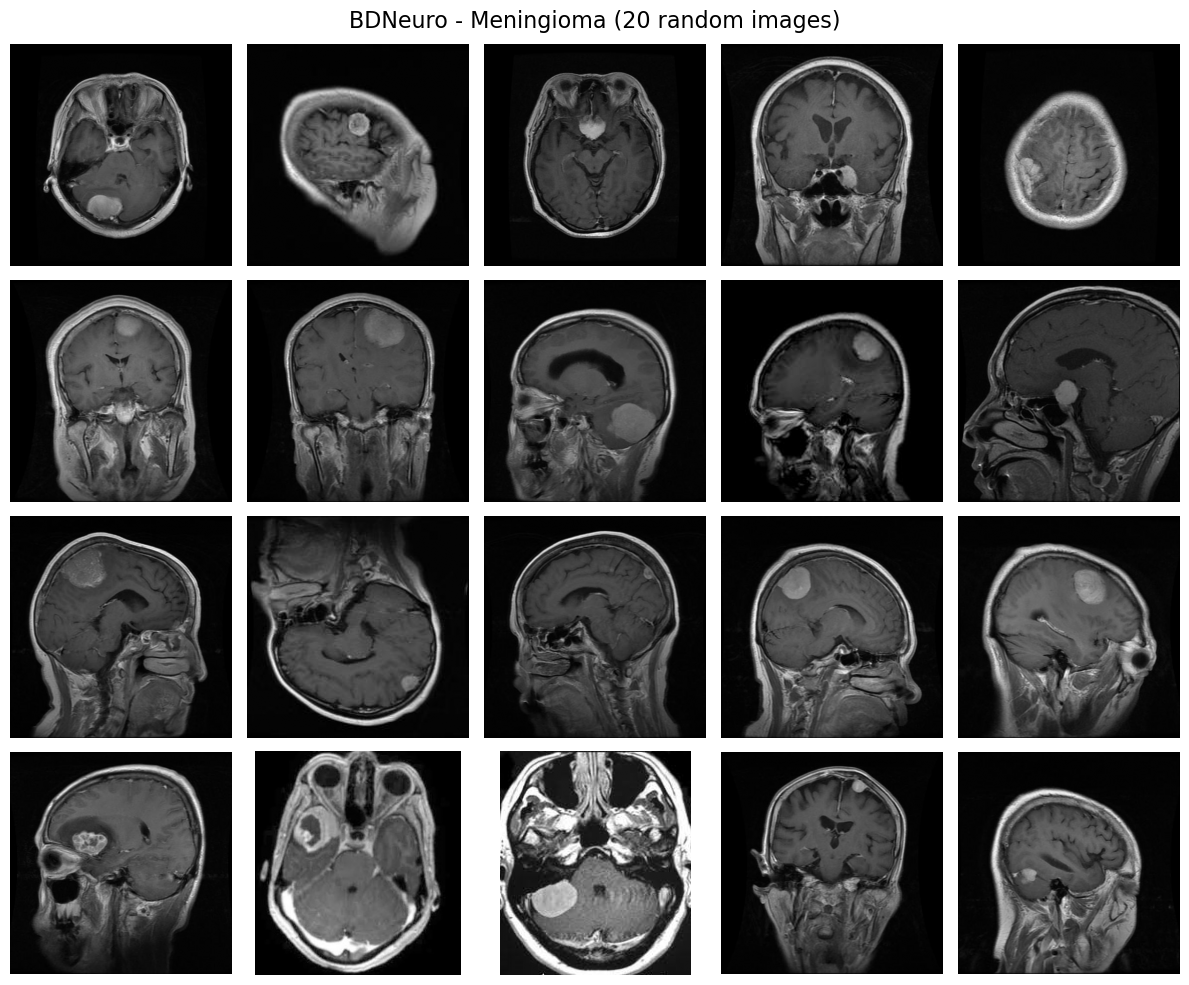

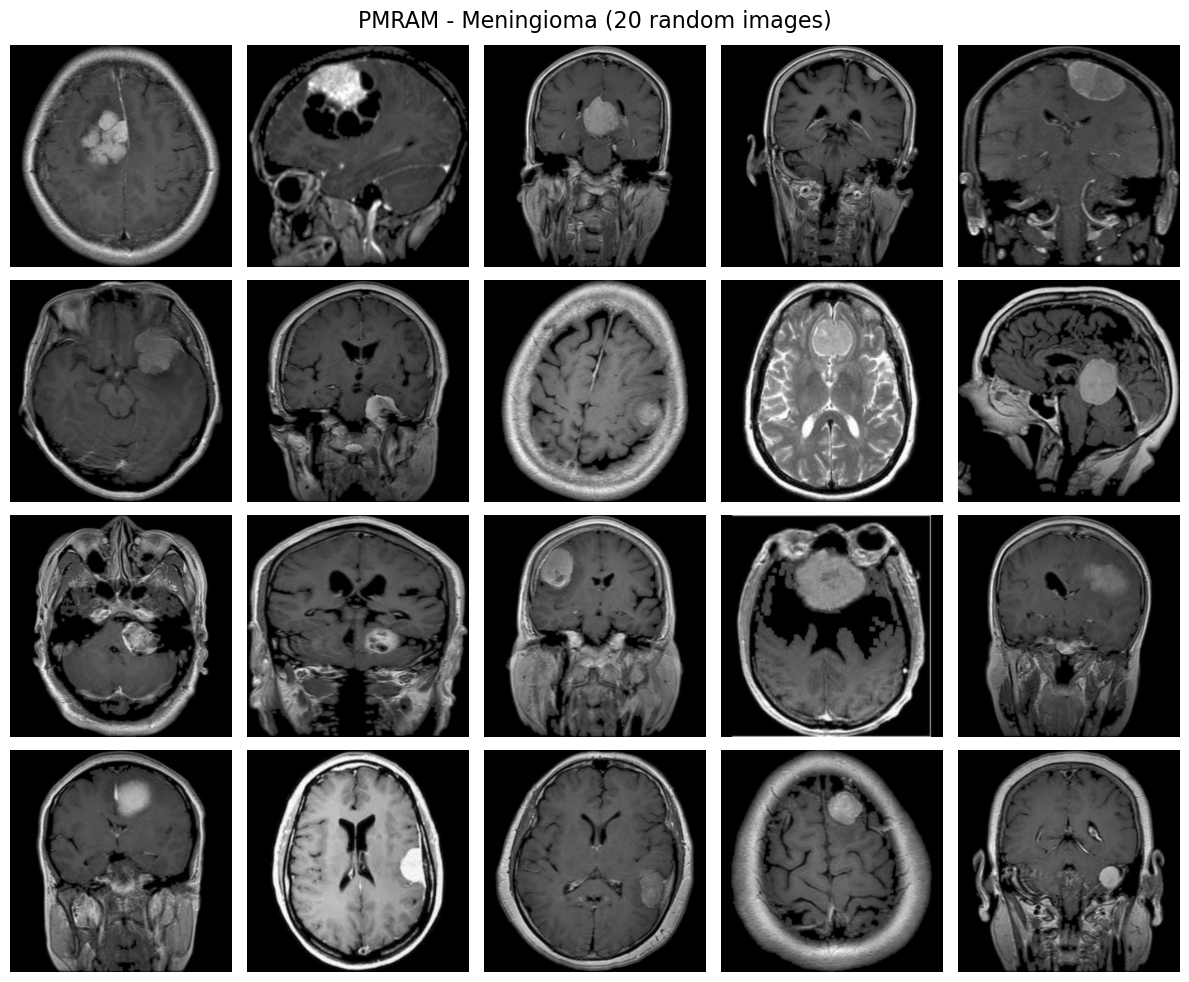

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

bd = df[
    (df["dataset"] == "BDNeuro") &
    (df["class_label"] == "meningioma")
].sample(n=20, random_state=42)

pm = df[
    (df["dataset"] == "PMRAM") &
    (df["class_label"] == "meningioma")
].sample(n=20, random_state=42)


def show_samples(data, title):

    fig, axes = plt.subplots(4, 5, figsize=(12, 10))

    for ax, (_, row) in zip(axes.flat, data.iterrows()):

        img = Image.open(row["filepath"]).convert("L")

        ax.imshow(img, cmap="gray")
        ax.axis("off")

    fig.suptitle(title, fontsize=16)

    plt.tight_layout()
    plt.show()


show_samples(bd, "BDNeuro - Meningioma (20 random images)")
show_samples(pm, "PMRAM - Meningioma (20 random images)")


In [27]:
import torch
import torch.nn as nn
from torchvision import models
from torch.utils.data import Dataset, DataLoader
from PIL import Image


# -------------------------
# 1. Device
# -------------------------
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# -------------------------
# 2. Dataset class
# -------------------------
class BrainMRIDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

        self.class_to_idx = {
            "glioma": 0,
            "meningioma": 1,
            "no_tumor": 2,
            "pituitary": 3
        }

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image = Image.open(row["filepath"]).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = self.class_to_idx[row["class_label"]]

        return image, label


# -------------------------
# 3. BDNeuro external loader
# -------------------------
bd_external_dataset = BrainMRIDataset(
    bdneuro_df,
    transform=eval_transform
)

bd_external_loader = DataLoader(
    bd_external_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

print("BDNeuro external images:", len(bd_external_dataset))


# -------------------------
# 4. Load PMRAM-trained EfficientNet
# -------------------------
model_pm_eff = models.efficientnet_b0(weights=None)

model_pm_eff.classifier[1] = nn.Linear(
    model_pm_eff.classifier[1].in_features,
    4
)

model_pm_eff.load_state_dict(
    torch.load(
        "efficientnet_b0_pmram_best.pth",
        map_location=device
    )
)

model_pm_eff = model_pm_eff.to(device)
model_pm_eff.eval()


# -------------------------
# 5. Final check
# -------------------------
print("\nMODEL AND LOADER RESTORED")
print("model_pm_eff:", 'model_pm_eff' in globals())
print("bd_external_loader:", 'bd_external_loader' in globals())
print("Number of BDNeuro batches:", len(bd_external_loader))


Device: cpu
BDNeuro external images: 5941

MODEL AND LOADER RESTORED
model_pm_eff: True
bd_external_loader: True
Number of BDNeuro batches: 372



## 3. Meningioma Failure Analysis

Because Meningioma exhibits the largest cross-dataset degradation, predictions from the PMRAM-trained EfficientNet-B0 model are examined in greater detail. Correctly and incorrectly classified BDNeuro Meningioma images are compared in terms of brightness, contrast, and image dimensions.

A Mann–Whitney U test is used to assess differences in image-level brightness and contrast between correct and incorrect predictions.

In [28]:

import torch
import pandas as pd

class_names = ["glioma", "meningioma", "no_tumor", "pituitary"]

model_pm_eff.eval()

results = []
global_index = 0

print("Starting Meningioma prediction analysis...")

with torch.no_grad():

    for batch_num, (images, labels) in enumerate(bd_external_loader):

        images = images.to(device)

        outputs = model_pm_eff(images)
        preds = outputs.argmax(dim=1).cpu()

        for i in range(len(labels)):

            true_label = labels[i].item()
            pred_label = preds[i].item()

            # Only true Meningioma images
            if true_label == 1:

                row = bdneuro_df.iloc[global_index + i]

                results.append({
                    "filepath": row["filepath"],
                    "true_class": "meningioma",
                    "predicted_class": class_names[pred_label],
                    "correct": pred_label == 1
                })

        global_index += len(labels)

        if (batch_num + 1) % 100 == 0:
            print(batch_num + 1, "/", len(bd_external_loader), "batches completed")


meningioma_predictions = pd.DataFrame(results)

print("\nFinished.")
print("Total Meningioma:", len(meningioma_predictions))
print("Correct:", meningioma_predictions["correct"].sum())
print("Wrong:", (~meningioma_predictions["correct"]).sum())

print("\nPredictions:")
print(meningioma_predictions["predicted_class"].value_counts())


meningioma_predictions.to_csv(
    "efficientnet_pmram_to_bdneuro_meningioma_predictions.csv",
    index=False
)

print("\nSaved: efficientnet_pmram_to_bdneuro_meningioma_predictions.csv")


Starting Meningioma prediction analysis...
100 / 372 batches completed
200 / 372 batches completed
300 / 372 batches completed

Finished.
Total Meningioma: 1478
Correct: 249
Wrong: 1229

Predictions:
predicted_class
glioma        612
no_tumor      323
pituitary     294
meningioma    249
Name: count, dtype: int64

Saved: efficientnet_pmram_to_bdneuro_meningioma_predictions.csv


In [29]:
import numpy as np
import pandas as pd
from PIL import Image

analysis_rows = []

print("Analyzing correct vs wrong Meningioma images...")

for i, row in meningioma_predictions.iterrows():

    img = Image.open(row["filepath"]).convert("L")
    arr = np.array(img, dtype=np.float32)

    brightness = arr.mean()
    contrast = arr.std()

    analysis_rows.append({
        "filepath": row["filepath"],
        "correct": row["correct"],
        "predicted_class": row["predicted_class"],
        "brightness": brightness,
        "contrast": contrast,
        "width": img.width,
        "height": img.height
    })

    if (i + 1) % 250 == 0:
        print(i + 1, "/", len(meningioma_predictions), "completed")


meningioma_correct_wrong_analysis = pd.DataFrame(analysis_rows)


summary = meningioma_correct_wrong_analysis.groupby("correct")[
    ["brightness", "contrast", "width", "height"]
].agg(["mean", "median", "std"])

print("\n======================================")
print("CORRECT vs WRONG MENINGIOMA")
print("======================================")
print(summary)

print("\nNumber of images:")
print(
    meningioma_correct_wrong_analysis["correct"]
    .value_counts()
    .rename(index={True: "Correct", False: "Wrong"})
)


meningioma_correct_wrong_analysis.to_csv(
    "meningioma_correct_vs_wrong_image_analysis.csv",
    index=False
)

summary.to_csv(
    "meningioma_correct_vs_wrong_summary.csv"
)

print("\nSaved:")
print("meningioma_correct_vs_wrong_image_analysis.csv")
print("meningioma_correct_vs_wrong_summary.csv")


Analyzing correct vs wrong Meningioma images...
250 / 1478 completed
500 / 1478 completed
750 / 1478 completed
1000 / 1478 completed
1250 / 1478 completed

CORRECT vs WRONG MENINGIOMA
        brightness                         contrast                        \
              mean     median        std       mean     median        std   
correct                                                                     
False    43.565895  41.578045  14.825296  45.204411  44.879391   7.709209   
True     49.729557  40.910999  22.005239  50.809124  48.495468  11.080628   

              width                         height                     
               mean median         std        mean median         std  
correct                                                                
False    413.047193  512.0  139.029650  414.050448  512.0  139.040526  
True     435.433735  512.0  132.632696  439.317269  512.0  129.059594  

Number of images:
correct
Wrong      1229
Correct     249
Name: count

In [30]:
from scipy.stats import mannwhitneyu

correct_df = meningioma_correct_wrong_analysis[
    meningioma_correct_wrong_analysis["correct"] == True
]

wrong_df = meningioma_correct_wrong_analysis[
    meningioma_correct_wrong_analysis["correct"] == False
]

for feature in ["brightness", "contrast"]:

    stat, p = mannwhitneyu(
        correct_df[feature],
        wrong_df[feature],
        alternative="two-sided"
    )

    print("\n", feature.upper())
    print("Correct mean:", round(correct_df[feature].mean(), 2))
    print("Wrong mean:", round(wrong_df[feature].mean(), 2))
    print("p-value:", p)



 BRIGHTNESS
Correct mean: 49.73
Wrong mean: 43.57
p-value: 0.11249198778044313

 CONTRAST
Correct mean: 50.81
Wrong mean: 45.2
p-value: 7.72710546852365e-15


## 4. Controlled Contrast Intervention

A controlled contrast intervention is performed to examine model sensitivity to image contrast. BDNeuro images are evaluated at multiple contrast factors while keeping the trained model unchanged.

The intervention is first examined for Meningioma and then across the full BDNeuro dataset to determine whether improvements in one class are associated with performance changes in other classes.



In [33]:
import torch
import pandas as pd
from PIL import Image, ImageEnhance
from torch.utils.data import Dataset, DataLoader


bd_men_df = bdneuro_df[
    bdneuro_df["class_label"] == "meningioma"
].copy().reset_index(drop=True)


class ContrastMeningiomaDataset(Dataset):

    def __init__(self, dataframe, contrast_factor):
        self.df = dataframe.reset_index(drop=True)
        self.contrast_factor = contrast_factor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = Image.open(
            row["filepath"]
        ).convert("RGB")

        # Contrast intervention
        if self.contrast_factor != 1.0:
            enhancer = ImageEnhance.Contrast(image)
            image = enhancer.enhance(
                self.contrast_factor
            )

        image = eval_transform(image)

        return image


contrast_factors = [
    0.75,
    1.00,
    1.25,
    1.50
]

results = []

model_pm_eff.eval()

for factor in contrast_factors:

    print(
        f"\nTesting contrast factor {factor}..."
    )

    dataset = ContrastMeningiomaDataset(
        bd_men_df,
        factor
    )

    loader = DataLoader(
        dataset,
        batch_size=16,
        shuffle=False,
        num_workers=0
    )

    predictions = []

    with torch.no_grad():

        for images in loader:

            images = images.to(device)

            outputs = model_pm_eff(images)

            preds = outputs.argmax(dim=1)

            predictions.extend(
                preds.cpu().numpy()
            )

    # Meningioma = class 1
    correct = sum(
        p == 1 for p in predictions
    )

    total = len(predictions)

    recall = correct / total

    results.append({
        "Contrast Factor": factor,
        "Correct Meningioma": correct,
        "Total": total,
        "Meningioma Recall": recall
    })

    print(
        "Correct:",
        correct,
        "/",
        total
    )

    print(
        "Recall:",
        round(recall, 4)
    )


contrast_intervention_results = pd.DataFrame(
    results
)

print("\n==============================")
print("CONTRAST INTERVENTION RESULTS")
print("==============================")

display(
    contrast_intervention_results
)


contrast_intervention_results.to_csv(
    "meningioma_contrast_intervention_results.csv",
    index=False
)

print(
    "\nSaved: meningioma_contrast_intervention_results.csv"
)



Testing contrast factor 0.75...
Correct: 213 / 1478
Recall: 0.1441

Testing contrast factor 1.0...
Correct: 249 / 1478
Recall: 0.1685

Testing contrast factor 1.25...
Correct: 634 / 1478
Recall: 0.429

Testing contrast factor 1.5...
Correct: 775 / 1478
Recall: 0.5244

CONTRAST INTERVENTION RESULTS


,Contrast Factor,Correct Meningioma,Total,Meningioma Recall
0,0.75,213,1478,0.144114
1,1.00,249,1478,0.168471
2,1.25,634,1478,0.428958
3,1.50,775,1478,0.524357



Saved: meningioma_contrast_intervention_results.csv


In [34]:
import torch
import pandas as pd
import numpy as np

from PIL import Image, ImageEnhance
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



class_names = [
    "glioma",
    "meningioma",
    "no_tumor",
    "pituitary"
]


class ContrastFullDataset(Dataset):

    def __init__(self, dataframe, contrast_factor):
        self.df = dataframe.reset_index(drop=True)
        self.contrast_factor = contrast_factor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = Image.open(
            row["filepath"]
        ).convert("RGB")

       
        if self.contrast_factor != 1.0:
            image = ImageEnhance.Contrast(
                image
            ).enhance(
                self.contrast_factor
            )

        image = eval_transform(image)

        label = class_names.index(
            row["class_label"]
        )

        return image, label


contrast_factors = [
    0.75,
    1.00,
    1.25,
    1.50
]

summary_results = []
all_reports = {}

model_pm_eff.eval()


for factor in contrast_factors:

    print("\n================================")
    print("Contrast Factor:", factor)
    print("================================")

    dataset = ContrastFullDataset(
        bdneuro_df,
        factor
    )

    loader = DataLoader(
        dataset,
        batch_size=16,
        shuffle=False,
        num_workers=0
    )

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model_pm_eff(images)

            preds = outputs.argmax(dim=1)

            y_true.extend(
                labels.numpy()
            )

            y_pred.extend(
                preds.cpu().numpy()
            )


    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    cm = confusion_matrix(
        y_true,
        y_pred
    )


    print(
        "Overall Accuracy:",
        round(accuracy, 4)
    )

    print("\nRecall by class:")

    for name in class_names:

        print(
            name,
            ":",
            round(
                report[name]["recall"],
                4
            )
        )


    print("\nConfusion Matrix:")
    print(cm)


    summary_results.append({

        "Contrast Factor": factor,

        "Accuracy": accuracy,

        "Glioma Recall":
            report["glioma"]["recall"],

        "Meningioma Recall":
            report["meningioma"]["recall"],

        "No Tumor Recall":
            report["no_tumor"]["recall"],

        "Pituitary Recall":
            report["pituitary"]["recall"],

        "Macro F1":
            report["macro avg"]["f1-score"]
    })


    all_reports[factor] = {
        "report": report,
        "confusion_matrix": cm
    }



contrast_full_results = pd.DataFrame(
    summary_results
)

print("\n\n================================")
print("FINAL CONTRAST RESULTS")
print("================================")

display(
    contrast_full_results.round(4)
)


contrast_full_results.to_csv(
    "full_bdneuro_contrast_intervention_results.csv",
    index=False
)

print(
    "\nSaved: full_bdneuro_contrast_intervention_results.csv"
)



Contrast Factor: 0.75
Overall Accuracy: 0.6756

Recall by class:
glioma : 0.8571
meningioma : 0.1441
no_tumor : 0.986
pituitary : 0.7724

Confusion Matrix:
[[1878   15  284   14]
 [ 636  213  262  367]
 [   4    3  776    4]
 [  26   31  281 1147]]

Contrast Factor: 1.0
Overall Accuracy: 0.6629

Recall by class:
glioma : 0.8357
meningioma : 0.1685
no_tumor : 0.9822
pituitary : 0.7306

Confusion Matrix:
[[1831    8  342   10]
 [ 612  249  323  294]
 [   6    5  773    3]
 [  19   30  351 1085]]

Contrast Factor: 1.25
Overall Accuracy: 0.6802

Recall by class:
glioma : 0.8498
meningioma : 0.429
no_tumor : 0.9733
pituitary : 0.5246

Confusion Matrix:
[[1862   32  295    2]
 [ 562  634  252   30]
 [   5   13  766    3]
 [ 128  278  300  779]]

Contrast Factor: 1.5
Overall Accuracy: 0.6304

Recall by class:
glioma : 0.8325
meningioma : 0.5244
no_tumor : 0.9682
pituitary : 0.2586

Confusion Matrix:
[[1824   52  315    0]
 [ 440  775  255    8]
 [   6   14  762    5]
 [ 124  668  309  384]]


,Contrast Factor,Accuracy,Glioma Recall,Meningioma Recall,No Tumor Recall,Pituitary Recall,Macro F1
0,0.75,0.6756,0.8571,0.1441,0.9860,0.7724,0.6119
1,1.00,0.6629,0.8357,0.1685,0.9822,0.7306,0.6054
2,1.25,0.6802,0.8498,0.4290,0.9733,0.5246,0.6553
3,1.50,0.6304,0.8325,0.5244,0.9682,0.2586,0.5876



Saved: full_bdneuro_contrast_intervention_results.csv


In [35]:

import pandas as pd
import numpy as np

class_names = [
    "glioma",
    "meningioma",
    "no_tumor",
    "pituitary"
]


cm_original = all_reports[1.00]["confusion_matrix"]


cm_125 = all_reports[1.25]["confusion_matrix"]


cm_change = cm_125 - cm_original


print("ORIGINAL — Contrast 1.00")
display(pd.DataFrame(
    cm_original,
    index=["True " + x for x in class_names],
    columns=["Pred " + x for x in class_names]
))

print("\nCONTRAST 1.25")
display(pd.DataFrame(
    cm_125,
    index=["True " + x for x in class_names],
    columns=["Pred " + x for x in class_names]
))

print("\nCHANGE: 1.25 minus 1.00")
print("Positive = more predictions")
print("Negative = fewer predictions")

change_df = pd.DataFrame(
    cm_change,
    index=["True " + x for x in class_names],
    columns=["Pred " + x for x in class_names]
)

display(change_df)

change_df.to_csv(
    "contrast_100_vs_125_confusion_change.csv"
)

print("\nSaved: contrast_100_vs_125_confusion_change.csv")


ORIGINAL — Contrast 1.00


,Pred glioma,Pred meningioma,Pred no_tumor,Pred pituitary
True glioma,1831,8,342,10
True meningioma,612,249,323,294
True no_tumor,6,5,773,3
True pituitary,19,30,351,1085



CONTRAST 1.25


,Pred glioma,Pred meningioma,Pred no_tumor,Pred pituitary
True glioma,1862,32,295,2
True meningioma,562,634,252,30
True no_tumor,5,13,766,3
True pituitary,128,278,300,779



CHANGE: 1.25 minus 1.00
Positive = more predictions
Negative = fewer predictions


,Pred glioma,Pred meningioma,Pred no_tumor,Pred pituitary
True glioma,31,24,-47,-8
True meningioma,-50,385,-71,-264
True no_tumor,-1,8,-7,0
True pituitary,109,248,-51,-306



Saved: contrast_100_vs_125_confusion_change.csv


## 5. Reverse-Direction Contrast Analysis

To examine whether contrast sensitivity is symmetric across datasets, the reverse direction is also evaluated. The EfficientNet-B0 model trained on BDNeuro is tested on PMRAM under the same controlled contrast factors.

This comparison helps distinguish direction-specific sensitivity from a general effect of contrast modification.




In [37]:
import torch
import torch.nn as nn
from torchvision import models


model_bd_eff = models.efficientnet_b0(weights=None)

model_bd_eff.classifier[1] = nn.Linear(
    model_bd_eff.classifier[1].in_features,
    4
)

model_bd_eff.load_state_dict(
    torch.load(
        "efficientnet_b0_bdneuro_best.pth",
        map_location=device
    )
)

model_bd_eff = model_bd_eff.to(device)
model_bd_eff.eval()

print("BD model restored successfully")


BD model restored successfully


In [38]:
import torch
import pandas as pd
from PIL import Image, ImageEnhance
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

class_names = [
    "glioma",
    "meningioma",
    "no_tumor",
    "pituitary"
]


class ContrastPMRAMDataset(Dataset):

    def __init__(self, dataframe, contrast_factor):
        self.df = dataframe.reset_index(drop=True)
        self.contrast_factor = contrast_factor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = Image.open(
            row["filepath"]
        ).convert("RGB")

        if self.contrast_factor != 1.0:
            image = ImageEnhance.Contrast(
                image
            ).enhance(
                self.contrast_factor
            )

        image = eval_transform(image)

        label = class_names.index(
            row["class_label"]
        )

        return image, label


contrast_factors = [
    0.75,
    1.00,
    1.25,
    1.50
]

reverse_results = []
reverse_reports = {}

model_bd_eff.eval()


for factor in contrast_factors:

    print("\n==============================")
    print("Contrast Factor:", factor)
    print("==============================")

    dataset = ContrastPMRAMDataset(
        pmram_df,
        factor
    )

    loader = DataLoader(
        dataset,
        batch_size=16,
        shuffle=False,
        num_workers=0
    )

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model_bd_eff(images)

            preds = outputs.argmax(dim=1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())


    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    cm = confusion_matrix(
        y_true,
        y_pred
    )


    print(
        "Overall Accuracy:",
        round(accuracy, 4)
    )

    print("\nRecall by class:")

    for name in class_names:
        print(
            name,
            ":",
            round(
                report[name]["recall"],
                4
            )
        )

    print("\nConfusion Matrix:")
    print(cm)


    reverse_results.append({

        "Contrast Factor": factor,

        "Accuracy": accuracy,

        "Glioma Recall":
            report["glioma"]["recall"],

        "Meningioma Recall":
            report["meningioma"]["recall"],

        "No Tumor Recall":
            report["no_tumor"]["recall"],

        "Pituitary Recall":
            report["pituitary"]["recall"],

        "Macro F1":
            report["macro avg"]["f1-score"]
    })


    reverse_reports[factor] = {
        "report": report,
        "confusion_matrix": cm
    }


reverse_contrast_results = pd.DataFrame(
    reverse_results
)

print("\n\n================================")
print("BDNEURO -> PMRAM")
print("FINAL CONTRAST RESULTS")
print("================================")

display(
    reverse_contrast_results.round(4)
)


reverse_contrast_results.to_csv(
    "pmram_contrast_intervention_bdneuro_model.csv",
    index=False
)

print(
    "\nSaved: pmram_contrast_intervention_bdneuro_model.csv"
)



Contrast Factor: 0.75
Overall Accuracy: 0.9475

Recall by class:
glioma : 0.9676
meningioma : 0.8226
no_tumor : 0.9912
pituitary : 0.9973

Confusion Matrix:
[[358   4   1   7]
 [  2 269  12  44]
 [  1   1 338   1]
 [  1   0   0 371]]

Contrast Factor: 1.0
Overall Accuracy: 0.9596

Recall by class:
glioma : 0.9757
meningioma : 0.8777
no_tumor : 0.9971
pituitary : 0.9812

Confusion Matrix:
[[361   5   2   2]
 [  6 287  13  21]
 [  1   0 340   0]
 [  3   4   0 365]]

Contrast Factor: 1.25
Overall Accuracy: 0.9574

Recall by class:
glioma : 0.9703
meningioma : 0.893
no_tumor : 0.9971
pituitary : 0.9651

Confusion Matrix:
[[359   6   4   1]
 [  5 292  13  17]
 [  1   0 340   0]
 [  6   5   2 359]]

Contrast Factor: 1.5
Overall Accuracy: 0.9454

Recall by class:
glioma : 0.9649
meningioma : 0.8654
no_tumor : 0.9971
pituitary : 0.9489

Confusion Matrix:
[[357   6   6   1]
 [ 12 283  20  12]
 [  1   0 340   0]
 [  7   6   6 353]]


BDNEURO -> PMRAM
FINAL CONTRAST RESULTS


,Contrast Factor,Accuracy,Glioma Recall,Meningioma Recall,No Tumor Recall,Pituitary Recall,Macro F1
0,0.75,0.9475,0.9676,0.8226,0.9912,0.9973,0.9459
1,1.00,0.9596,0.9757,0.8777,0.9971,0.9812,0.9583
2,1.25,0.9574,0.9703,0.8930,0.9971,0.9651,0.9565
3,1.50,0.9454,0.9649,0.8654,0.9971,0.9489,0.9440



Saved: pmram_contrast_intervention_bdneuro_model.csv
